In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

dfs_raw = {
    2015: pd.read_csv(r'C:\Users\santa\Desktop\ETL_cositas\workshop_03\data\raw\2015.csv'),
    2016: pd.read_csv(r'C:\Users\santa\Desktop\ETL_cositas\workshop_03\data\raw\2016.csv'),
    2017: pd.read_csv(r'C:\Users\santa\Desktop\ETL_cositas\workshop_03\data\raw\2017.csv'),
    2018: pd.read_csv(r'C:\Users\santa\Desktop\ETL_cositas\workshop_03\data\raw\2018.csv'),
    2019: pd.read_csv(r'C:\Users\santa\Desktop\ETL_cositas\workshop_03\data\raw\2019.csv'),
}

In [7]:
for year, df in dfs_raw.items():
    print(f"  year {year}: {df.shape[0]} rows × {df.shape[1]} columns")
    display(df.head(3))

  year 2015: 158 rows × 12 columns


,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738
1,Iceland,Western Europe,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201
2,Denmark,Western Europe,3,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204


  year 2016: 157 rows × 13 columns


,Country,Region,Happiness Rank,Happiness Score,Lower Confidence Interval,Upper Confidence Interval,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Denmark,Western Europe,1,7.526,7.460,7.592,1.44178,1.16374,0.79504,0.57941,0.44453,0.36171,2.73939
1,Switzerland,Western Europe,2,7.509,7.428,7.590,1.52733,1.14524,0.86303,0.58557,0.41203,0.28083,2.69463
2,Iceland,Western Europe,3,7.501,7.333,7.669,1.42666,1.18326,0.86733,0.56624,0.14975,0.47678,2.83137


  year 2017: 155 rows × 12 columns


,Country,Happiness.Rank,Happiness.Score,Whisker.high,Whisker.low,Economy..GDP.per.Capita.,Family,Health..Life.Expectancy.,Freedom,Generosity,Trust..Government.Corruption.,Dystopia.Residual
0,Norway,1,7.537,7.594445,7.479556,1.616463,1.533524,0.796667,0.635423,0.362012,0.315964,2.277027
1,Denmark,2,7.522,7.581728,7.462272,1.482383,1.551122,0.792566,0.626007,0.355280,0.400770,2.313707
2,Iceland,3,7.504,7.622030,7.385970,1.480633,1.610574,0.833552,0.627163,0.475540,0.153527,2.322715


  year 2018: 156 rows × 9 columns


,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.632,1.305,1.592,0.874,0.681,0.202,0.393
1,2,Norway,7.594,1.456,1.582,0.861,0.686,0.286,0.340
2,3,Denmark,7.555,1.351,1.590,0.868,0.683,0.284,0.408


  year 2019: 156 rows × 9 columns


,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341


In [8]:
for year, df in dfs_raw.items():
    print(f"\n{year}: {list(df.columns)}")


2015: ['Country', 'Region', 'Happiness Rank', 'Happiness Score', 'Standard Error', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual']

2016: ['Country', 'Region', 'Happiness Rank', 'Happiness Score', 'Lower Confidence Interval', 'Upper Confidence Interval', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual']

2017: ['Country', 'Happiness.Rank', 'Happiness.Score', 'Whisker.high', 'Whisker.low', 'Economy..GDP.per.Capita.', 'Family', 'Health..Life.Expectancy.', 'Freedom', 'Generosity', 'Trust..Government.Corruption.', 'Dystopia.Residual']

2018: ['Overall rank', 'Country or region', 'Score', 'GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']

2019: ['Overall rank', 'Country or region', 'Score', 'GDP per capita', 'Socia

In [9]:
for year, df in dfs_raw.items():
    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0]
    status = nulls.to_dict() if not nulls.empty else "no nulls"
    print(f"{year}: {status}")

2015: no nulls
2016: no nulls
2017: no nulls
2018: {'Perceptions of corruption': 1}
2019: no nulls


In [14]:
for year, df in dfs_raw.items():
    dupes = df.duplicated().sum()
    print(f"{year}: {dupes} duplicate rows")

2015: 0 duplicate rows
2016: 0 duplicate rows
2017: 0 duplicate rows
2018: 0 duplicate rows
2019: 0 duplicate rows


In [ ]:
score_col = {
    2015: 'Happiness Score',
    2016: 'Happiness Score',
    2017: 'Happiness.Score',
    2018: 'Score',
    2019: 'Score',
}

stats = []
for year, col in score_col.items():
    s = dfs_raw[year][col]
    stats.append({
        'year':  year,
        'count': s.count(),
        'mean':  round(s.mean(), 3),
        'std':   round(s.std(), 3),
        'min':   round(s.min(), 3),
        'max':   round(s.max(), 3),
    })

pd.DataFrame(stats).set_index('year')

,count,mean,std,min,max
year,,,,,
2015,158,5.376,1.145,2.839,7.587
2016,157,5.382,1.142,2.905,7.526
2017,155,5.354,1.131,2.693,7.537
2018,156,5.376,1.120,2.905,7.632
2019,156,5.407,1.113,2.853,7.769


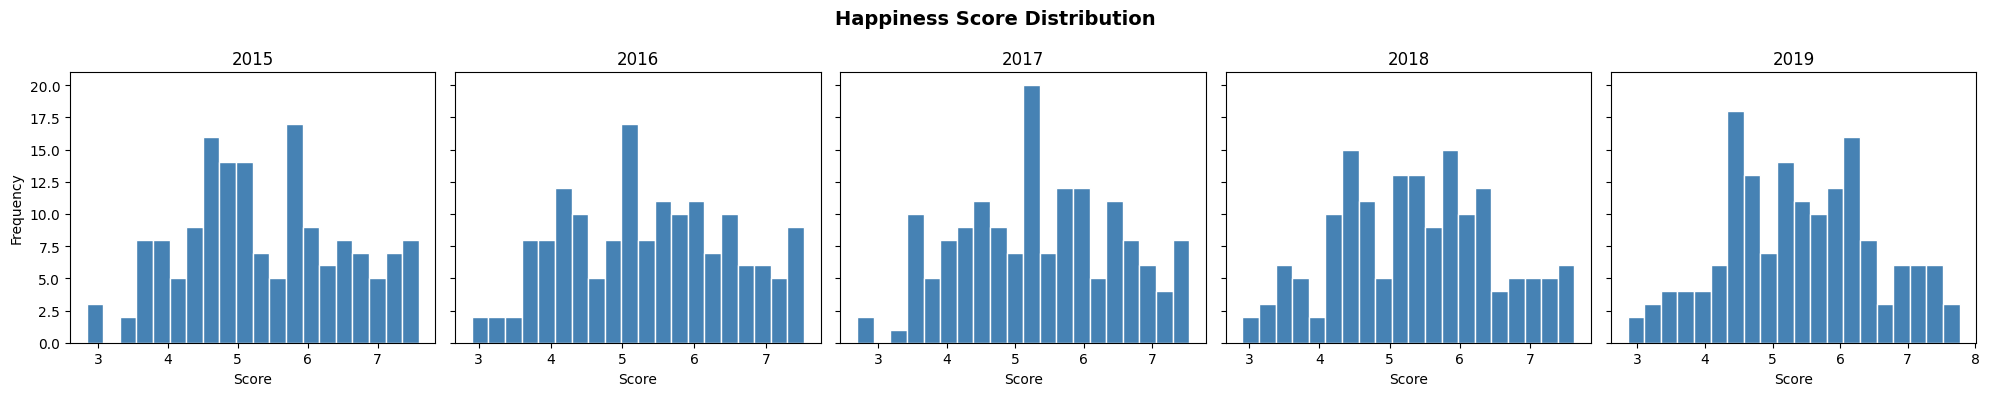

In [17]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)

for ax, (year, col) in zip(axes, score_col.items()):
    dfs_raw[year][col].plot(kind='hist', bins=20, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(str(year))
    ax.set_xlabel('Score')

axes[0].set_ylabel('Frequency')
fig.suptitle('Happiness Score Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [21]:
country_col = {
    2015: 'Country', 2016: 'Country', 2017: 'Country',
    2018: 'Country or region', 2019: 'Country or region'
}

sets = {year: set(df[col].str.strip()) for year, (df, col) in 
        zip(dfs_raw.keys(), [(dfs_raw[y], country_col[y]) for y in dfs_raw])}

all_countries  = set.union(*sets.values())
common         = set.intersection(*sets.values())
only_some      = all_countries - common

print(f"Total different countries:          {len(all_countries)}")
print(f"Countries in all 5 years:            {len(common)}")
print(f"Countries missing from some years:     {len(only_some)}")
print(f"\nInconsistent countries:\n{sorted(only_some)}")

Total different countries:          170
Countries in all 5 years:            141
Countries missing from some years:     29

Inconsistent countries:
['Angola', 'Belize', 'Central African Republic', 'Comoros', 'Djibouti', 'Gambia', 'Hong Kong', 'Hong Kong S.A.R., China', 'Laos', 'Lesotho', 'Macedonia', 'Mozambique', 'Namibia', 'North Cyprus', 'North Macedonia', 'Northern Cyprus', 'Oman', 'Puerto Rico', 'Somalia', 'Somaliland Region', 'Somaliland region', 'South Sudan', 'Sudan', 'Suriname', 'Swaziland', 'Taiwan', 'Taiwan Province of China', 'Trinidad & Tobago', 'Trinidad and Tobago']


In [25]:
for year, df in dfs_raw.items():
    tiene = 'Region' in df.columns
    print(f"{year}: {'region column exists' if tiene else 'region column missing'}")

2015: region column exists
2016: region column exists
2017: region column missing
2018: region column missing
2019: region column missing


In [26]:
summary = {
    "Columns to rename":                "all of them:  canonical schema (country, score, gdp, family, health, freedom, generosity, trust)",
    "Columns to delete":                "Standard Error, Confidence Intervals, Whisker.high/low, Dystopia Residual",
    "year column":                      "add year column to each df",
    "Nulls":                            "only 2015 has one null so i can impute with median",
    "region column":                    "only 2018 and 2019 have it, so drop it",
    "countries with different names":   "Unify: Taiwan, North Cyprus, Trinidad & Tobago, etc.",
    "Duplicates":                       "no duplicates found",
}

pd.DataFrame(summary.items(), columns=['Problem', 'Decision'])

,Problem,Decision
0,Columns to rename,"all of them: canonical schema (country, score..."
1,Columns to delete,"Standard Error, Confidence Intervals, Whisker...."
2,year column,add year column to each df
3,Nulls,only 2015 has one null so i can impute with me...
4,region column,"only 2018 and 2019 have it, so drop it"
5,countries with different names,"Unify: Taiwan, North Cyprus, Trinidad & Tobago..."
6,Duplicates,no duplicates found
